<a href="https://colab.research.google.com/github/ARedRaider4Life/automatic-train/blob/main/Trusted_Surgeon_Recommender_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. Creating Synthetic Data ---
Synthetic data created successfully.
--- 2. Calculating True Trust Score ---
Trust score calculated and normalized.
--- 3. Training a RandomForest Model ---

Model Performance:
  RMSE: 0.0170
  R^2:  0.9836

--- Top 10 Recommended Surgeons ---
     surgeon_id         npi hospital_name  predicted_trust  true_trust_score  \
857         857  1000000857   Hospital_77            0.986             0.997   
329         329  1000000329   Hospital_10            0.973             0.985   
644         644  1000000644  Hospital_143            0.973             0.998   
112         112  1000000112   Hospital_10            0.972             0.980   
152         152  1000000152  Hospital_100            0.966             0.976   
309         309  1000000309   Hospital_14            0.964             1.000   
290         290  1000000290   Hospital_14            0.958             0.958   
821         821  1000000821   Hospital_72            0.958             0.969   
3

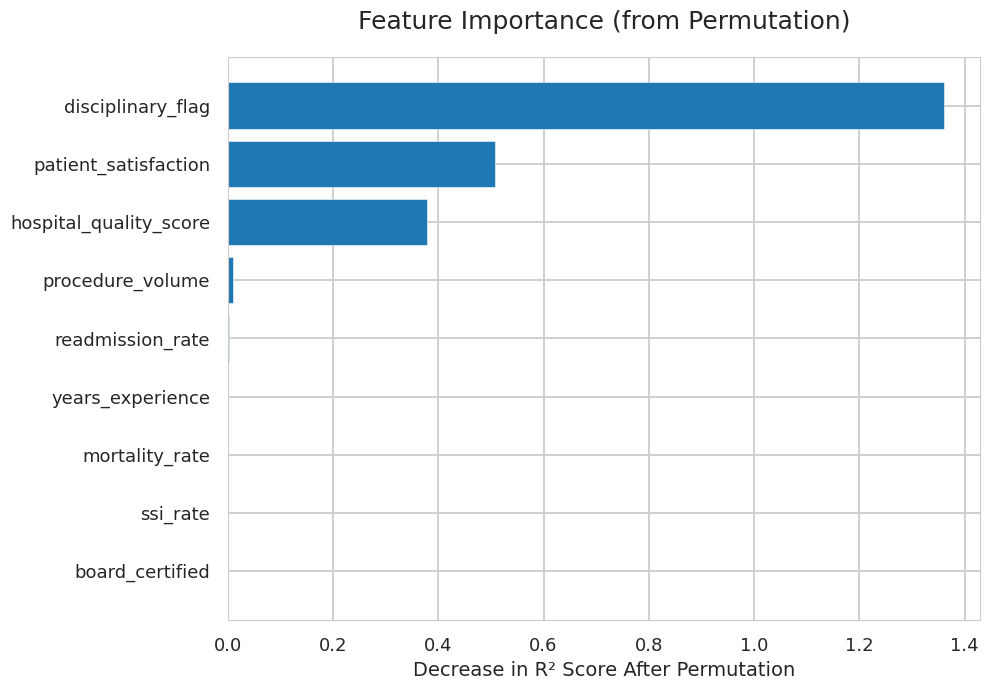

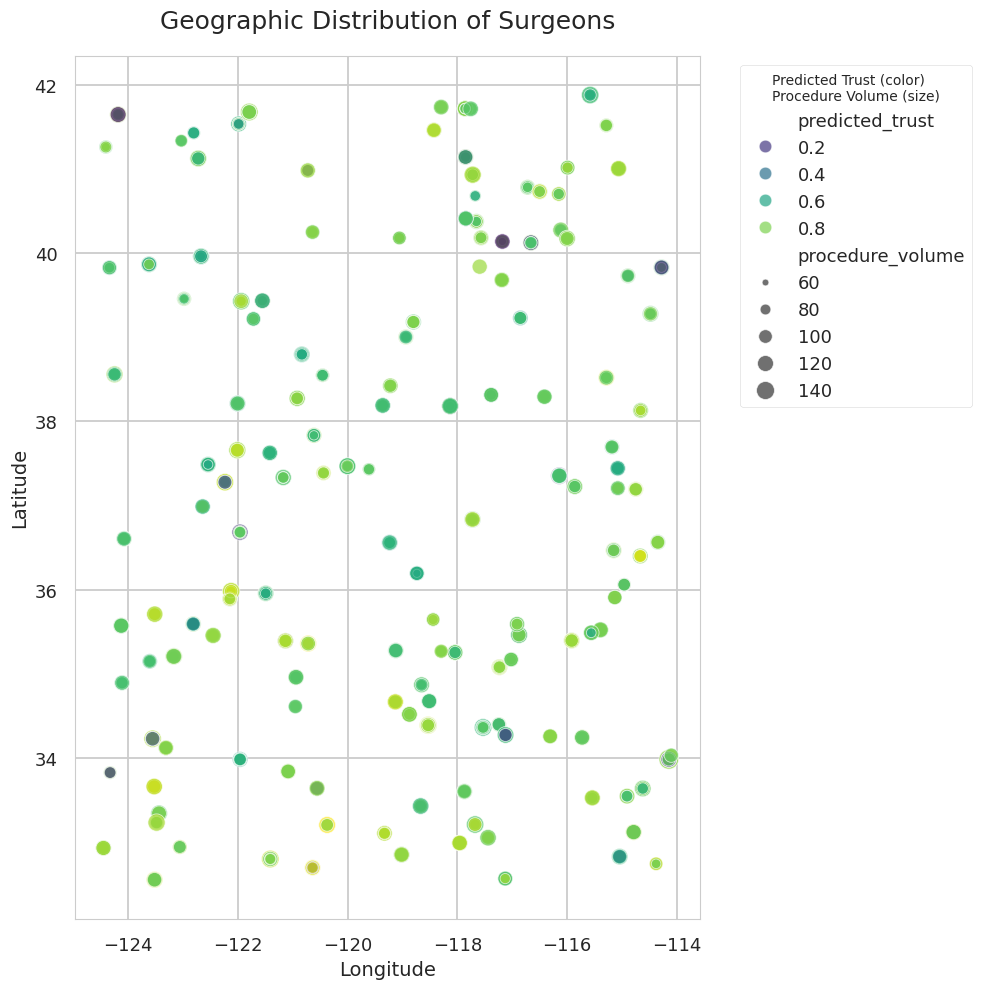

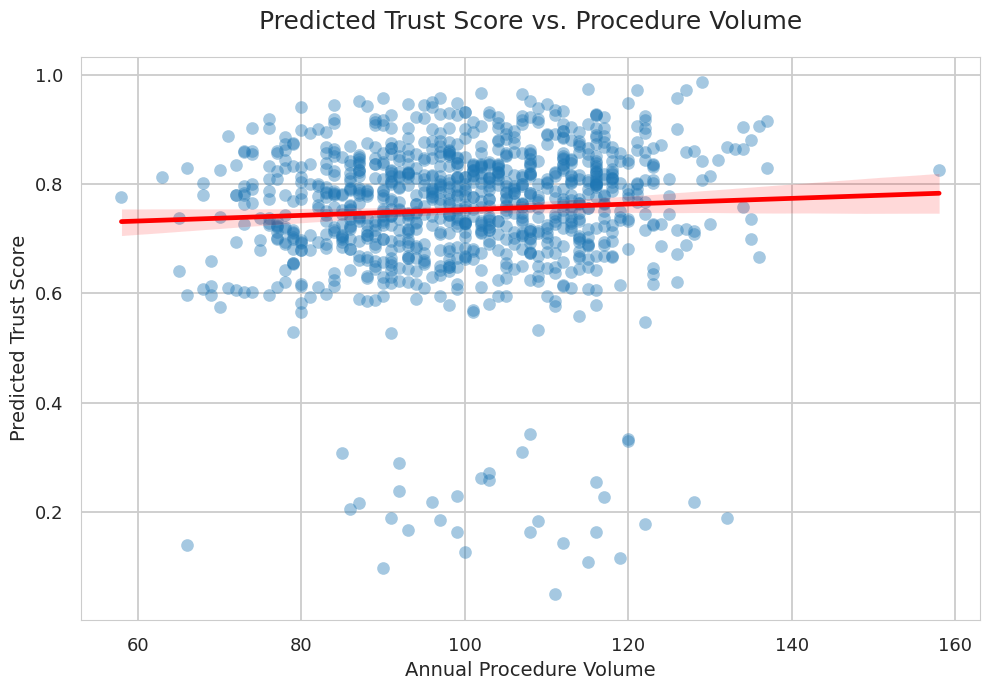

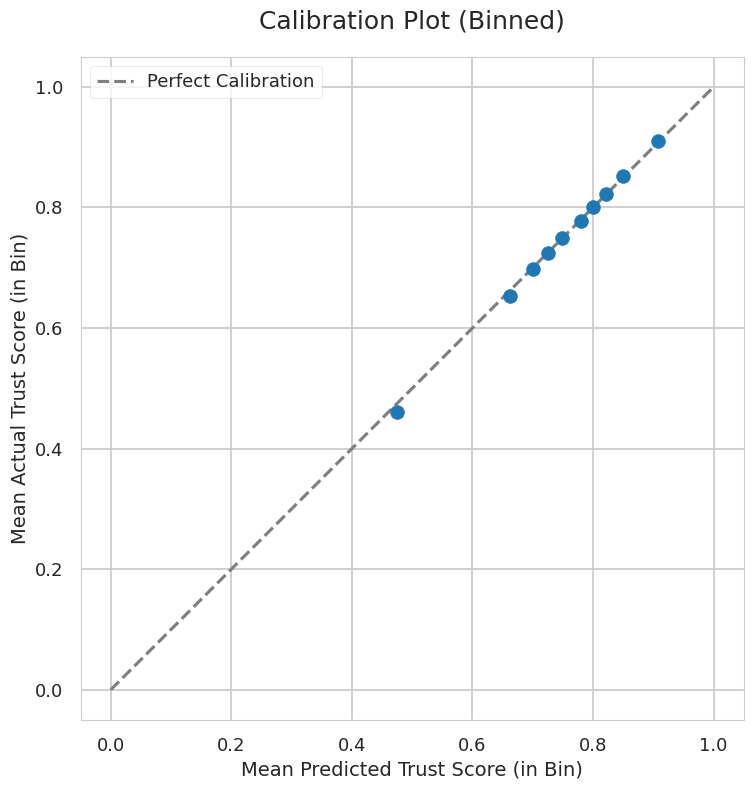

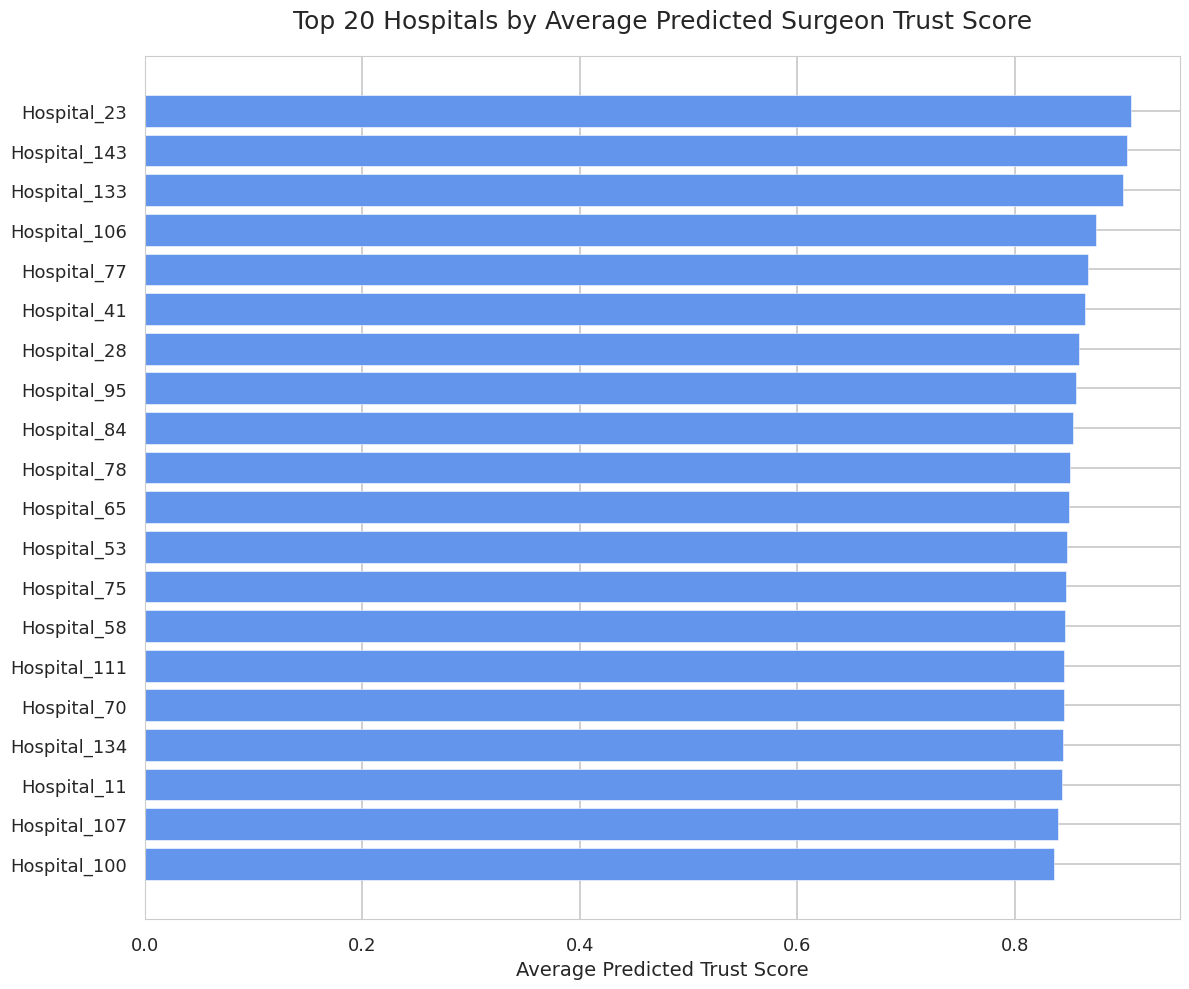


--- 5. Performing Advanced Statistical Analysis ---


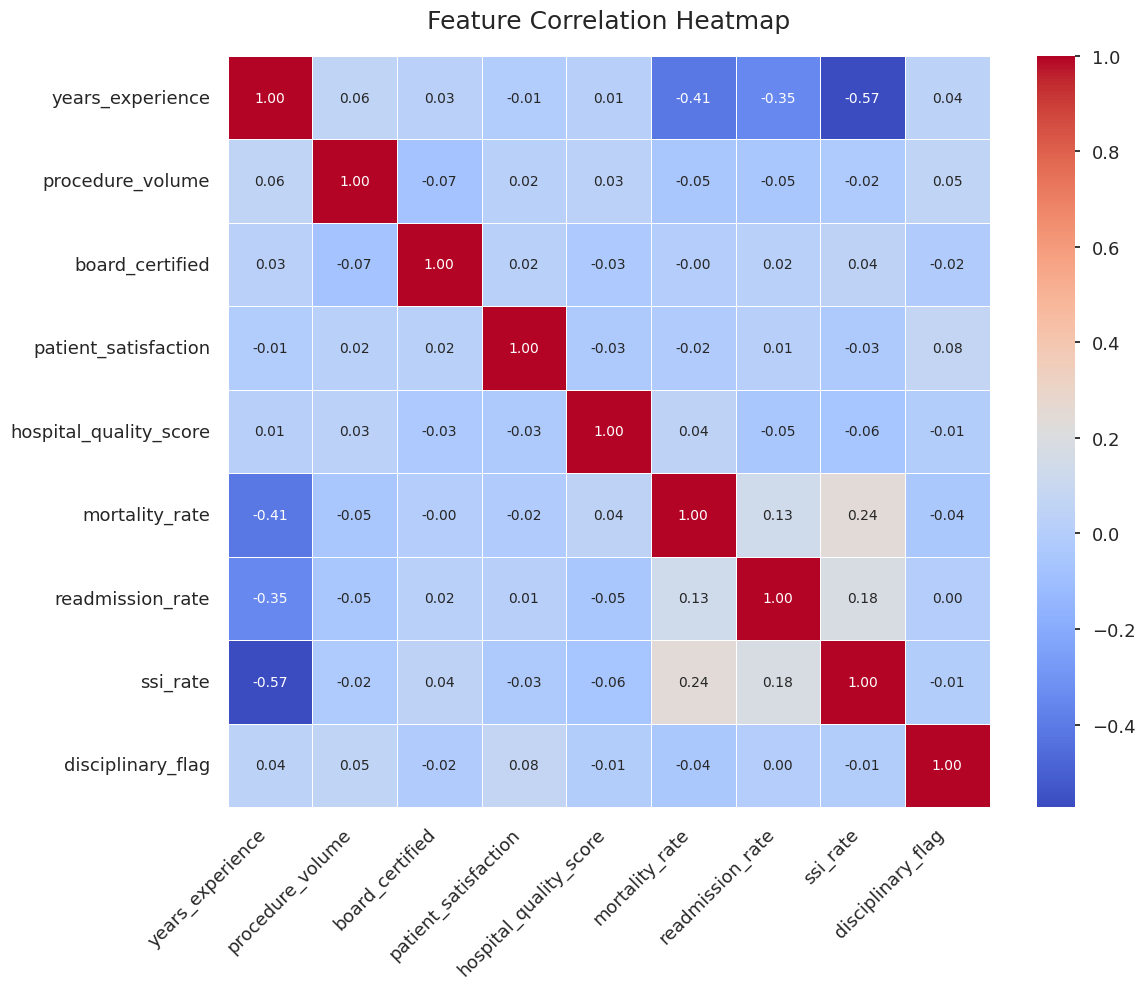

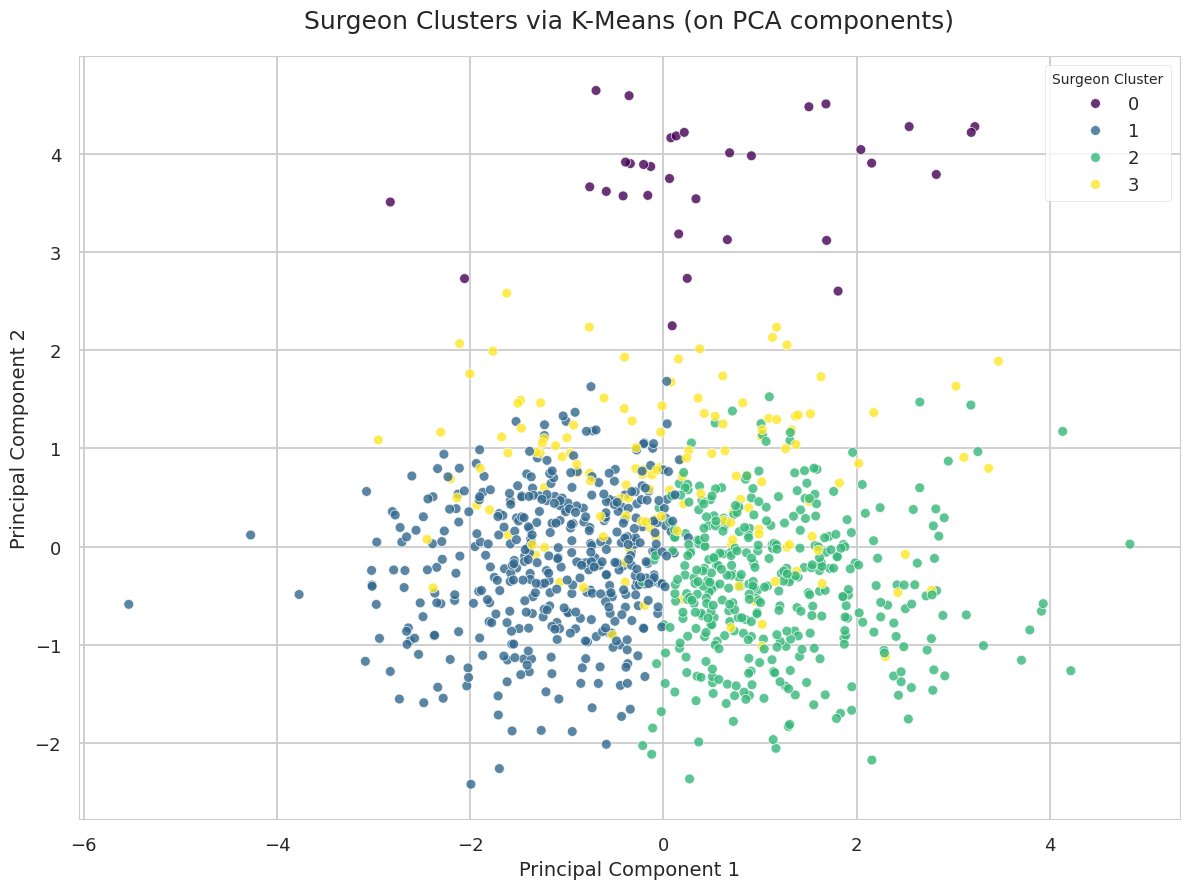


--- Surgeon Cluster Profiles (Mean Values) ---
         years_experience  procedure_volume  board_certified  \
cluster                                                        
0                  14.057           104.273            0.818   
1                   8.053            97.614            1.000   
2                  17.583           101.291            1.000   
3                  12.080           102.507            0.000   

         patient_satisfaction  hospital_quality_score  mortality_rate  \
cluster                                                                 
0                       4.393                   0.712           0.027   
1                       4.256                   0.708           0.033   
2                       4.106                   0.726           0.025   
3                       4.177                   0.728           0.029   

         readmission_rate  ssi_rate  disciplinary_flag  
cluster                                                 
0             

/tmp/ipython-input-847641580.py:329: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


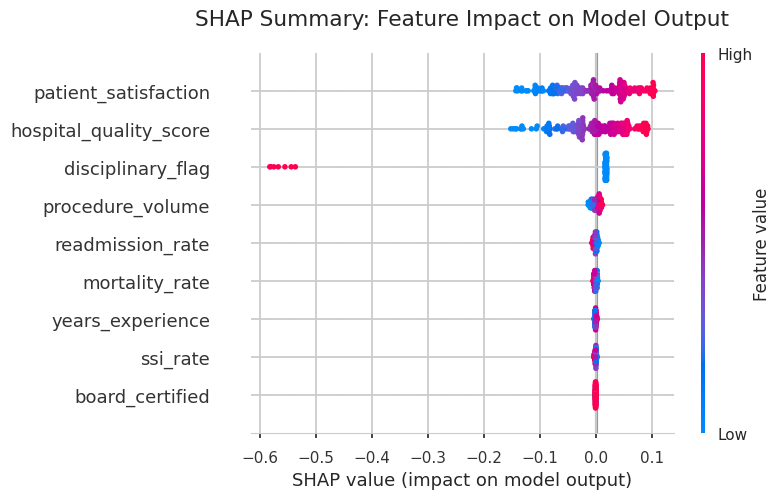

In [ ]:
# -*- coding: utf-8 -*-
"""
Surgeon Recommendation Engine

This script demonstrates a complete machine learning pipeline to recommend surgeons
based on a composite score that maps to active surgeons

The script performs the following steps:
1.  Generates a synthetic dataset mimicking real-world surgeon and hospital data
    in California. This includes metrics like experience, procedure volume,
    patient satisfaction, and various quality outcome rates.
2.  Calculates a composite 'true_trust_score' to serve as the target variable
    for a regression model. This score is a weighted combination of positive
    and negative factors.
3.  Trains a RandomForestRegressor model to predict the trust score based on
    surgeon and hospital features.
4.  Evaluates the model's performance using R-squared and RMSE metrics.
5.  Generates and displays five business-focused visualizations to analyze the
    data and model predictions, including feature importance, geographic
    distribution, and model calibration.
6.  Performs advanced statistical analysis, including PCA, K-Means Clustering,
    and SHAP analysis to uncover deeper insights.
7.  Identifies and outputs the top-recommended surgeons based on the predicted
    trust score.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import shap
import os

# --- 1. Synthetic Data Creation ---
def create_synthetic_data(n_surgeons=1000, n_hospitals=150):
    """
    Generates synthetic data for surgeons and hospitals in California.

    Args:
        n_surgeons (int): The number of surgeons to generate.
        n_hospitals (int): The number of hospitals to generate.

    Returns:
        pandas.DataFrame: A DataFrame containing the combined surgeon and hospital data.
    """
    print("--- 1. Creating Synthetic Data ---")
    np.random.seed(42)

    # Generate hospitals with lat/lon roughly in CA bounding box
    hospitals = pd.DataFrame({
        'hospital_id': np.arange(n_hospitals),
        'hospital_name': [f'Hospital_{i}' for i in range(n_hospitals)],
        'lat': np.random.uniform(32.5, 42.0, n_hospitals),
        'lon': np.random.uniform(-124.5, -114.0, n_hospitals),
        # hospital_quality_score is a proxy for overall hospital quality (0-1)
        'hospital_quality_score': np.random.beta(5, 2, n_hospitals)
    })

    # Generate surgeon-level records
    surgeons = pd.DataFrame({
        'surgeon_id': np.arange(n_surgeons),
        'npi': 1000000000 + np.arange(n_surgeons),  # Synthetic NPIs
        'hospital_id': np.random.choice(hospitals['hospital_id'], n_surgeons),
        'years_experience': np.clip(np.random.normal(12, 7, n_surgeons), 1, 50),
        'procedure_volume': np.clip(np.random.poisson(80, n_surgeons) + np.random.randint(0, 40, n_surgeons), 5, 200),
        'board_certified': np.random.binomial(1, 0.85, n_surgeons),
        'disciplinary_flag': np.random.binomial(1, 0.03, n_surgeons),  # Small % have flags
        'patient_satisfaction': np.clip(np.random.normal(4.2, 0.5, n_surgeons), 1.5, 5.0)
    })

    # Merge hospital features into the surgeons dataframe
    surgeons = surgeons.merge(hospitals, on='hospital_id', how='left')

    # Add synthetic outcome metrics (rates) — lower is better for these
    surgeons['mortality_rate'] = np.clip(np.random.beta(2, 200, n_surgeons) + 0.0005 * (50 - surgeons['years_experience']), 0, 0.1)
    surgeons['readmission_rate'] = np.clip(np.random.beta(5, 150, n_surgeons) + 0.0008 * (50 - surgeons['years_experience']), 0, 0.15)
    surgeons['ssi_rate'] = np.clip(np.random.beta(3, 300, n_surgeons) + 0.0006 * (50 - surgeons['years_experience']), 0, 0.08)

    print("Synthetic data created successfully.")
    return surgeons

# --- 2. Target Variable Calculation ---
def calculate_trust_score(df):
    """
    Calculates the 'true_trust_score' based on a weighted formula.

    This score combines positive drivers (satisfaction, volume) and negative
    drivers (mortality, readmission, disciplinary flags) into a single metric.

    Args:
        df (pandas.DataFrame): The surgeons DataFrame.

    Returns:
        pandas.DataFrame: The DataFrame with the 'true_trust_score' column added.
    """
    print("--- 2. Calculating True Trust Score ---")
    # Weighted combination of factors
    trust_score = (
        0.35 * (df['patient_satisfaction'] / 5.0) +
        0.25 * (np.log1p(df['procedure_volume']) / np.log1p(200)) +
        0.20 * df['hospital_quality_score'] -
        0.40 * df['mortality_rate'] -
        0.25 * df['readmission_rate'] -
        0.15 * df['ssi_rate'] -
        0.30 * df['disciplinary_flag']
    )
    # Normalize the score to a 0-1 scale
    min_val = trust_score.min()
    max_val = trust_score.max()
    df['true_trust_score'] = (trust_score - min_val) / (max_val - min_val)

    print("Trust score calculated and normalized.")
    return df

# --- 3. Model Training and Prediction ---
def train_and_predict(df):
    """
    Trains a RandomForestRegressor and generates predictions.

    Args:
        df (pandas.DataFrame): The complete dataset.

    Returns:
        tuple: A tuple containing the trained model, test data (X_test, y_test),
               and predictions.
    """
    print("--- 3. Training a RandomForest Model ---")
    features = [
        'years_experience', 'procedure_volume', 'board_certified', 'patient_satisfaction',
        'hospital_quality_score', 'mortality_rate', 'readmission_rate', 'ssi_rate', 'disciplinary_flag'
    ]
    X = df[features]
    y = df['true_trust_score']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=150, random_state=42)
    rf.fit(X_train, y_train)

    predictions = rf.predict(X_test)

    # Evaluate and print metrics
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"\nModel Performance:\n  RMSE: {np.sqrt(mse):.4f}\n  R^2:  {r2:.4f}\n")

    return rf, (X_train, X_test, y_train, y_test), predictions

# --- 4. Visualization ---
def create_visualizations(df, model, test_data, predictions):
    """
    Generates and displays visualizations for data and model insights.

    Args:
        df (pandas.DataFrame): The full dataset with predictions.
        model (RandomForestRegressor): The trained model.
        test_data (tuple): Contains X_train, X_test, y_train, y_test.
        predictions (np.array): The model's predictions on the test set.
    """
    print("--- 4. Generating Visualizations ---")
    sns.set_style("whitegrid")
    plt.style.use('seaborn-v0_8-talk')
    _, X_test, _, y_test = test_data

    # --- Viz 1: Feature Importance ---
    perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': perm.importances_mean
    }).sort_values('importance_mean', ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(importance_df['feature'], importance_df['importance_mean'])
    plt.title('Feature Importance (from Permutation)', fontsize=18, pad=20)
    plt.xlabel('Decrease in R² Score After Permutation', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- Viz 2: Geographic Distribution of Surgeons ---
    plt.figure(figsize=(10, 10))
    sns.scatterplot(
        data=df,
        x='lon',
        y='lat',
        size='procedure_volume',
        hue='predicted_trust',
        palette='viridis',
        sizes=(20, 200),
        alpha=0.7
    )
    plt.title('Geographic Distribution of Surgeons', fontsize=18, pad=20)
    plt.xlabel('Longitude', fontsize=14)
    plt.ylabel('Latitude', fontsize=14)
    plt.legend(title='Predicted Trust (color)\nProcedure Volume (size)', bbox_to_anchor=(1.05, 1), loc=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Viz 3: Trust Score vs. Procedure Volume ---
    plt.figure(figsize=(10, 7))
    sns.regplot(
        x='procedure_volume',
        y='predicted_trust',
        data=df,
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'red'}
    )
    plt.title('Predicted Trust Score vs. Procedure Volume', fontsize=18, pad=20)
    plt.xlabel('Annual Procedure Volume', fontsize=14)
    plt.ylabel('Predicted Trust Score', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Viz 4: Model Calibration Plot ---
    calibration_df = pd.DataFrame({
        'predicted': predictions,
        'actual': y_test,
        'bin': pd.qcut(predictions, 10, duplicates='drop', labels=False)
    }).groupby('bin').agg({'predicted': 'mean', 'actual': 'mean'}).reset_index()

    plt.figure(figsize=(8, 8))
    plt.scatter(calibration_df['predicted'], calibration_df['actual'], s=100, zorder=3)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.title('Calibration Plot (Binned)', fontsize=18, pad=20)
    plt.xlabel('Mean Predicted Trust Score (in Bin)', fontsize=14)
    plt.ylabel('Mean Actual Trust Score (in Bin)', fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.axis('square')
    plt.tight_layout()
    plt.show()

    # --- Viz 5: Top 20 Hospitals by Average Surgeon Trust Score ---
    hospital_agg = df.groupby('hospital_name').agg(
        predicted_trust_mean=('predicted_trust', 'mean'),
        num_surgeons=('surgeon_id', 'count')
    ).sort_values('predicted_trust_mean', ascending=True).tail(20)

    plt.figure(figsize=(12, 10))
    plt.barh(hospital_agg.index, hospital_agg['predicted_trust_mean'], color='cornflowerblue')
    plt.title('Top 20 Hospitals by Average Predicted Surgeon Trust Score', fontsize=18, pad=20)
    plt.xlabel('Average Predicted Trust Score', fontsize=14)
    plt.tight_layout()
    plt.show()

# --- 5. Advanced Statistical Analysis ---
def perform_advanced_analysis(df, model, test_data):
    """
    Performs advanced analysis like PCA, Clustering, and SHAP.

    Args:
        df (pandas.DataFrame): The full dataset.
        model (RandomForestRegressor): The trained model.
        test_data (tuple): Contains X_train, X_test, y_train, y_test.
    """
    print("\n--- 5. Performing Advanced Statistical Analysis ---")
    features = [
        'years_experience', 'procedure_volume', 'board_certified', 'patient_satisfaction',
        'hospital_quality_score', 'mortality_rate', 'readmission_rate', 'ssi_rate', 'disciplinary_flag'
    ]
    X = df[features]
    _, X_test, _, _ = test_data

    # --- Analysis 1: Correlation Heatmap ---
    plt.figure(figsize=(12, 10))
    corr = X.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
    plt.title('Feature Correlation Heatmap', fontsize=18, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --- Analysis 2: PCA and K-Means Clustering ---
    # Scale data for PCA and Clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df[['PC1', 'PC2']] = X_pca

    # K-Means Clustering
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)

    # Visualize Clusters on PCA components
    plt.figure(figsize=(12, 9))
    sns.scatterplot(
        data=df,
        x='PC1',
        y='PC2',
        hue='cluster',
        palette='viridis',
        alpha=0.8,
        s=50
    )
    plt.title('Surgeon Clusters via K-Means (on PCA components)', fontsize=18, pad=20)
    plt.xlabel('Principal Component 1', fontsize=14)
    plt.ylabel('Principal Component 2', fontsize=14)
    plt.legend(title='Surgeon Cluster')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print cluster characteristics
    print("\n--- Surgeon Cluster Profiles (Mean Values) ---")
    cluster_profiles = df.groupby('cluster')[features].mean().round(3)
    print(cluster_profiles)
    print("-" * 45)


    # --- Analysis 3: SHAP (SHapley Additive exPlanations) ---
    print("\nCalculating SHAP values for model explainability...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title("SHAP Summary: Feature Impact on Model Output", pad=20)
    plt.tight_layout()
    plt.show()


# --- Main Execution ---
def main():
    """Main function to run the data analysis pipeline."""
    # Step 1: Create data
    surgeon_df = create_synthetic_data()

    # Step 2: Calculate target variable
    surgeon_df_with_score = calculate_trust_score(surgeon_df)

    # Step 3: Train model and get predictions
    model, test_data, predictions = train_and_predict(surgeon_df_with_score)

    # Add model predictions to the main DataFrame for visualization
    all_features = surgeon_df_with_score[
        ['years_experience', 'procedure_volume', 'board_certified', 'patient_satisfaction',
        'hospital_quality_score', 'mortality_rate', 'readmission_rate', 'ssi_rate', 'disciplinary_flag']
    ]
    surgeon_df_with_score['predicted_trust'] = model.predict(all_features)

    # --- Identify and print top surgeons ---
    top_recs = surgeon_df_with_score.sort_values('predicted_trust', ascending=False).head(10)
    print("--- Top 10 Recommended Surgeons ---")
    print(top_recs[[
        'surgeon_id', 'npi', 'hospital_name', 'predicted_trust',
        'true_trust_score', 'procedure_volume', 'patient_satisfaction'
    ]].round(3))
    print("-" * 35)

    # Step 4: Create and display visualizations
    create_visualizations(surgeon_df_with_score, model, test_data, predictions)

    # Step 5: Perform and display advanced analysis
    perform_advanced_analysis(surgeon_df_with_score, model, test_data)

if __name__ == "__main__":
    main()